# Differentiable design of a pair-conversion tracker with an anticoincidence detector (ACD)

**Setup.** A monoenergetic photon beam hits the detector at normal incidence. The detector is a stack of
tungsten converter layers, each followed by two silicon strip planes (x and y), wrapped in a plastic
scintillator ACD that vetoes charged particles.

**Goal.** Choose the geometry that maximises the significance of a point-like signal on top of a diffuse
photon background and a charged-particle background.

**Method.** The whole detector response is a closed-form, differentiable function of the design parameters,
so JAX can give us the gradient of the significance with respect to every parameter and Adam can climb it.
The significance is the expected (Asimov) likelihood ratio of the data with and without a point source, integrated
over the sky around the source. Each conversion layer is its own pseudo-detector with its own PSF, and the
per-layer results are summed (see the README for the reasoning). The old single-cone count is kept as a check.
All numbers are placeholders: set realistic ones before trusting any optimum.

**Naming.** camelCase everywhere, no unit suffixes. ACD is treated as a word (`acdThickness`).

**Units.** Lengths in cm, energies in MeV, times in s, solid angles in sr, fluxes in 1/(cm^2 s).
Angular variances are in rad^2. The angular resolution reported in the plots is in degrees.
Units are also given at the end of the line where each input is defined.

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import optax
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# 64-bit floats: the significance formula subtracts large, similar numbers, and float32 loses precision there.
jax.config.update("jax_enable_x64", True)

## Fixed inputs
These are not optimised. If the optimiser could change them it would simply run to the bounds.

In [2]:
# Every number is followed by its unit and its source: a physical constant, a link, or "Placeholder" when no source has
# been found yet. Bibliography keys (in brackets) are in references/bibliography.bib, with local copies of the sources.
# Reference values and the open decisions for each placeholder are in PARAMETERS.md.

# Radiation lengths of the materials.
radiationLengthTungsten = 0.3504       # cm. Physical constant: tungsten radiation length [pdg2024tungsten] https://pdg.lbl.gov/2024/AtomicNuclearProperties/HTML/tungsten_W.html
radiationLengthSilicon = 9.37          # cm. Physical constant: silicon radiation length [pdg2024silicon] https://pdg.lbl.gov/2024/AtomicNuclearProperties/HTML/silicon_Si.html
radiationLengthScintillator = 42.4     # cm. Physical constant: polyvinyltoluene scintillator is 42.54 cm [pdg2024pvt] https://pdg.lbl.gov/2024/AtomicNuclearProperties/HTML/polyvinyltoluene.html. 42.4 is slightly off, to update.

# Pair conversion probability after x radiation lengths is 1 - exp(-7/9 * x), the high energy limit.
pairConversionCoefficientPerRadiationLength = 7.0 / 9.0   # Physical constant: sigma = 7/9 A/(X0 N_A), PDG Eq. 34.32 [pdg2024passage] https://pdg.lbl.gov/2024/reviews/rpp2024-rev-passage-particles-matter.pdf. Accurate to a few percent only down to 1 GeV, so optimistic at 100 MeV.

numberOfLayers = 10                    # Discrete, so it is scanned by hand rather than optimised. Placeholder. Reference: LAT 18 x-y layers, 16 with tungsten [atwood2009lat] https://arxiv.org/abs/0902.1089 section 2.2.1; HERD FIT 7 double layers [farina2021herd] https://doi.org/10.22323/1.395.0651 section 2.
photonEnergy = 100.0                   # MeV. Placeholder, to be replaced by a truncated power law (README). Fixed because there is no calorimeter: energy is not a free measurement.
electronMass = 0.511                   # MeV. Physical constant: electron mass, PDG https://pdg.lbl.gov/2024/
detectorSideLength = 40.0              # cm. Placeholder. Reference: LAT is 1.8 m wide [atwood2009lat] https://arxiv.org/abs/0902.1089 Fig. 1. Decision pending (PARAMETERS.md).
siliconThickness = 0.03                # cm, thickness of one silicon plane. Placeholder. Reference: LAT strip detectors are 400 um = 0.04 cm [atwood2009lat] https://arxiv.org/abs/0902.1089 section 2.2.1.

# Fluxes and observation conditions.
signalPhotonFlux = 1e-3                # 1/(cm^2 s). Placeholder, very bright. Reference: 1e-7 above 100 MeV for a faint high-latitude source [atwood2009lat] https://arxiv.org/abs/0902.1089 Table 1 note d.
diffusePhotonFlux = 1e-2               # 1/(cm^2 s) over the field of view. Placeholder. Reference: 1.5e-5 per cm^2 s sr above 100 MeV at high latitude, index 2.1 [atwood2009lat] https://arxiv.org/abs/0902.1089 Table 1 note e.
chargedParticleFlux = 1.0              # 1/(cm^2 s). Placeholder. Reference: about 0.1 inferred from the LAT raw trigger rate of 2-4 kHz over about 3.2e4 cm^2 [atwood2009lat] https://arxiv.org/abs/0902.1089 section 2.2.3.
exposureDuration = 1e4                 # s. Placeholder. Reference: LAT 1-year survey [atwood2009lat] https://arxiv.org/abs/0902.1089 Table 1 note d; HERD 1, 5 and 10 years [farina2021herd] https://doi.org/10.22323/1.395.0651 Fig. 3.
fieldOfViewSolidAngle = 1.0            # sr. Placeholder. Reference: LAT 2.4 sr at 1 GeV [atwood2009lat] https://arxiv.org/abs/0902.1089 section 2.1.

# Constraints that keep the optimum finite. Without them the optimiser drives the strip pitch to its
# lower bound and makes the detector as tall and channel-rich as allowed.
channelBudget = 5e4                    # number of strips. Placeholder, no source found. Scales with detector size, decision pending.
maximumHeight = 30.0                   # cm. Placeholder. Reference: LAT whole instrument is 0.72 m high, tracker alone not found [atwood2009lat] https://arxiv.org/abs/0902.1089 Fig. 1.

# A track needs hits in the layers below the conversion point to be reconstructed.
minimumDownstreamLayersForReconstruction = 3   # Placeholder. HERD needs at least 3 hits per particle in each of X and Y, which rejects the last two double layers, so 2 [farina2021herd] https://doi.org/10.22323/1.395.0651 section 4.

# Multiple scattering: scattering in downstream material is counted with this reduced weight (toy value).
downstreamScatteringWeight = 1.0 / 3.0   # Toy value, no source.

# Signal region: a cone around the source with this radius, in units of the angular resolution.
signalConeRadiusInSigma = 2.0          # Only used by the single-cone check. The objective has no cone. Analysis convention, no source. The Gaussian 68% radius is 1.51 sigma (computed from 1 - exp(-r^2/2)).

# Spatial likelihood ratio (the objective). The sky around the source is integrated out to the field of view.
numberOfReconstructableLayers = numberOfLayers - minimumDownstreamLayersForReconstruction   # Layers that can be a conversion layer. Derived.
fieldOfViewRadius = float(np.arccos(1.0 - fieldOfViewSolidAngle / (2.0 * np.pi)))   # rad. Derived, exact: half-angle of a circular cap of that solid angle, Omega = 2 pi (1 - cos(theta)). Mathematical result, no source.
radialGridMinimum = 1e-4               # rad. Innermost radius of the logarithmic integration grid. Numerical choice, no physical source.
radialGridPoints = 2000                # Numerical choice, checked against the analytic limit in the checks below.
minimumSignalPhotons = 10.0            # Soft constraint. Fermi-LAT sensitivity definition: at least 10 photons [fermilat2013performance] https://s3df.slac.stanford.edu/data/fermi/groups/canda/archive/pass8v6/lat_Performance.htm; HERD [farina2021herd] https://doi.org/10.22323/1.395.0651 section 6.

# Conversion-layer classes ("pseudo-detectors"). confusionMatrix[assigned, true] is the probability that a photon
# that converted in layer `true` is assigned to layer `assigned`, so each column sums to one.
labelConfusionMatrix = jnp.eye(numberOfReconstructableLayers)   # Perfect labels. The default and an upper bound. Definition, no source.
noLabelConfusionMatrix = jnp.full((numberOfReconstructableLayers,) * 2, 1.0 / numberOfReconstructableLayers)   # No labels. A lower bound. Definition: every class equally likely.
# The charged-particle background that leaks through the ACD is assigned to the first layer: a charged track has hits from the top.
chargedBackgroundLayerShare = jnp.zeros(numberOfReconstructableLayers).at[0].set(1.0)   # All in layer 0. Modelling decision, see the open issue in the README.

# Plastic scintillator ACD.
minimumIonisingEnergyLossPerLength = 2.019   # MeV/cm, energy deposited by a minimum ionising particle. Physical constant: polyvinyltoluene, 1.956 MeV cm^2/g at 1.032 g/cm^3 [pdg2024pvt] https://pdg.lbl.gov/2024/AtomicNuclearProperties/HTML/polyvinyltoluene.html
maximumVetoEfficiency = 0.999          # Placeholder. Reference: LAT tile efficiency above 0.9997 averaged over the ACD area [atwood2009lat] https://arxiv.org/abs/0902.1089 section 2.2.3 and Table 4.
vetoTurnOnWidthFraction = 0.25         # Width of the efficiency turn-on, as a fraction of the deposit. Toy value, no source.
accidentalVetoScale = 0.1              # MeV. Sets how fast noise-induced dead time falls with threshold. Toy value, no source.

# Allowed range of each free parameter. Optimisation runs in an unbounded space (see below).
parameterBounds = {
    # cm, one value per layer. Never zero: passive material always converts some photons. Lower bound 1e-3 is a placeholder, optimistic: LAT passive material is 0.014 X0 per x-y plane, about 0.005 cm of tungsten [atwood2009lat] https://arxiv.org/abs/0902.1089 Table 2. Upper bound 0.2 is a placeholder (LAT back foils are 0.072 cm, Table 2).
    "converterThickness": (1e-3, 0.2),
    # cm. Placeholder range. Reference: LAT about 3.2 cm, from pitch 0.0228 cm / 0.0071 [atwood2009lat] https://arxiv.org/abs/0902.1089 Table 2.
    "layerSpacing": (0.5, 5.0),
    # cm. Placeholder range. Reference: LAT 228 um = 0.0228 cm [atwood2009lat] https://arxiv.org/abs/0902.1089 Table 2; HERD FIT about 250 um [farina2021herd] https://doi.org/10.22323/1.395.0651 section 2.
    "stripPitch": (0.005, 0.1),
    # cm. Placeholder range. Reference: LAT 1.0 cm [atwood2009lat] https://arxiv.org/abs/0902.1089 Table 4.
    "acdThickness": (0.5, 3.0),
    # MeV. Placeholder range. Reference: LAT 0.45 MIP on board and about 0.30 MIP on the ground [atwood2009lat] https://arxiv.org/abs/0902.1089 section 2.2.3.
    "acdThreshold": (0.05, 1.0),
}


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


## Detector model

The optimiser works on *unbounded* numbers. A sigmoid maps each one into its allowed range, so the
parameters can never leave the physical region and no clipping (which has zero gradient) is needed.

In [3]:
def mapUnboundedToRange(unboundedValue, lowerBound, upperBound):
    return lowerBound + (upperBound - lowerBound) * jax.nn.sigmoid(unboundedValue)


def mapUnboundedToPhysicalParameters(unboundedParameters):
    return {
        parameterName: mapUnboundedToRange(unboundedParameters[parameterName], *parameterBounds[parameterName])
        for parameterName in parameterBounds
    }

In [4]:
# Layers below each layer, used both to decide if a track can be reconstructed and for the lever arm.
numberOfLayersBelow = numberOfLayers - 1 - jnp.arange(numberOfLayers)


def computeLayerMaterial(converterThickness):
    """Material in each layer, and above and below it, in radiation lengths."""
    # Material in one layer: tungsten converter plus one silicon plane.
    converterRadiationLengths = converterThickness / radiationLengthTungsten
    radiationLengthsPerLayer = converterRadiationLengths + siliconThickness / radiationLengthSilicon

    # Material the photon crosses before reaching a layer, and material the pair crosses after leaving it.
    radiationLengthsAboveLayer = jnp.cumsum(radiationLengthsPerLayer) - radiationLengthsPerLayer
    radiationLengthsBelowLayer = jnp.sum(radiationLengthsPerLayer) - jnp.cumsum(radiationLengthsPerLayer)
    return converterRadiationLengths, radiationLengthsAboveLayer, radiationLengthsBelowLayer


def computeConversionProbabilityPerLayer(converterRadiationLengths, radiationLengthsAboveLayer):
    """Probability that the photon converts in each layer and leaves a reconstructable track."""
    hasEnoughDownstreamLayers = (numberOfLayersBelow >= minimumDownstreamLayersForReconstruction).astype(float)

    # Photon survives the layers above, then converts in this layer's tungsten. Silicon is ignored as a converter.
    return (
        jnp.exp(-pairConversionCoefficientPerRadiationLength * radiationLengthsAboveLayer)
        * (1.0 - jnp.exp(-pairConversionCoefficientPerRadiationLength * converterRadiationLengths))
        * hasEnoughDownstreamLayers
    )


def computePerLayerAngularVariance(converterRadiationLengths, radiationLengthsBelowLayer, layerSpacing, stripPitch):
    """Angular variance (rad^2) of the reconstructed direction for a photon that converted in each layer."""
    # Three independent contributions, added in quadrature (variances in rad^2), evaluated per conversion layer.
    # 1. Multiple scattering (Highland formula without the log term). Each pair member carries half the energy.
    #    The conversion happens on average halfway through its own converter.
    radiationLengthsTraversedByPair = (
        0.5 * converterRadiationLengths + downstreamScatteringWeight * radiationLengthsBelowLayer   # 0.5: conversion halfway through its own foil on average. Toy assumption, no source.
    )
    multipleScatteringVariance = (13.6 / (photonEnergy / 2.0)) ** 2 * radiationLengthsTraversedByPair   # 13.6 MeV: Highland-Lynch-Dahl constant, PDG Eq. 34.16 [pdg2024passage] https://pdg.lbl.gov/2024/reviews/rpp2024-rev-passage-particles-matter.pdf. 2.0: each pair member carries half the energy, an approximation.
    # 2. Intrinsic opening angle of the pair.
    pairOpeningAngleVariance = (electronMass / photonEnergy) ** 2   # m_e / E: characteristic scale of the pair opening angle, an approximation with no single source.
    # 3. Strip resolution (pitch / sqrt(12) for a uniform hit distribution) over the lever arm to the last layer.
    leverArm = jnp.maximum(numberOfLayersBelow, 1) * layerSpacing   # cm
    stripResolutionVariance = 2.0 * (stripPitch / jnp.sqrt(12.0) / leverArm) ** 2   # 12: variance of a uniform distribution over one pitch is pitch^2/12, standard result (see PDG detectors review [pdg2024detectors] https://pdg.lbl.gov/2024/reviews/rpp2024-rev-particle-detectors-accel.pdf). 2.0: toy factor, no source.

    return multipleScatteringVariance + pairOpeningAngleVariance + stripResolutionVariance


def computeEffectiveAngularVariance(
    converterRadiationLengths, radiationLengthsBelowLayer, conversionProbabilityPerLayer, layerSpacing, stripPitch
):
    """Variance averaged over conversion layers. Only the single-cone check uses this, the objective keeps each layer."""
    angularVariancePerLayer = computePerLayerAngularVariance(
        converterRadiationLengths, radiationLengthsBelowLayer, layerSpacing, stripPitch
    )
    return jnp.sum(conversionProbabilityPerLayer * angularVariancePerLayer) / jnp.sum(conversionProbabilityPerLayer)


def computeSignalConeFractions(effectiveAngularVariance):
    """How much signal the signal cone keeps, and how much of the background it lets in."""
    signalConeSolidAngle = jnp.pi * signalConeRadiusInSigma**2 * effectiveAngularVariance   # sr
    backgroundFractionInsideCone = signalConeSolidAngle / fieldOfViewSolidAngle
    # Fraction of a 2D Gaussian inside a circle of the given radius in sigma.
    signalContainmentFraction = 1.0 - jnp.exp(-(signalConeRadiusInSigma**2) / 2.0)   # 2.0: from the 2D Gaussian containment, mathematical result.
    return signalContainmentFraction, backgroundFractionInsideCone


def computeAcdResponse(acdThickness, acdThreshold):
    """Charged-particle veto efficiency, photon survival through the ACD, and livetime lost to noise."""
    energyDepositedInAcd = minimumIonisingEnergyLossPerLength * acdThickness   # MeV
    # Smooth turn-on of the charged-particle detection efficiency around the threshold.
    vetoEfficiency = maximumVetoEfficiency * jax.nn.sigmoid(
        (energyDepositedInAcd - acdThreshold) / (vetoTurnOnWidthFraction * energyDepositedInAcd)
    )
    # A photon that converts inside the ACD is vetoed by mistake ("self-veto"), so a thick ACD costs signal.
    photonSurvivalProbabilityThroughAcd = jnp.exp(
        -pairConversionCoefficientPerRadiationLength * acdThickness / radiationLengthScintillator
    )
    # Low thresholds trigger the veto on noise, which removes livetime. Toy model, falls exponentially.
    livetimeFraction = jnp.exp(-jnp.exp(-acdThreshold / accidentalVetoScale))
    return vetoEfficiency, photonSurvivalProbabilityThroughAcd, livetimeFraction


def computeExpectedCounts(
    totalConversionProbability, signalContainmentFraction, backgroundFractionInsideCone,
    vetoEfficiency, photonSurvivalProbabilityThroughAcd, livetimeFraction,
):
    """Expected signal and background counts over the exposure."""
    detectorArea = detectorSideLength**2   # cm^2
    exposureFactor = detectorArea * exposureDuration * livetimeFraction

    signalCount = (
        signalPhotonFlux * exposureFactor * totalConversionProbability
        * photonSurvivalProbabilityThroughAcd * signalContainmentFraction
    )
    # Two backgrounds: diffuse photons that convert like the signal, and charged particles the veto misses.
    backgroundCount = exposureFactor * backgroundFractionInsideCone * (
        diffusePhotonFlux * totalConversionProbability * photonSurvivalProbabilityThroughAcd
        + chargedParticleFlux * (1.0 - vetoEfficiency)
    )
    return signalCount, backgroundCount


def computeCountsPerLayer(conversionProbabilityPerLayer, vetoEfficiency, photonSurvivalProbabilityThroughAcd, livetimeFraction):
    """Expected signal and background counts over the field of view, for each true conversion layer."""
    exposureFactor = detectorSideLength**2 * exposureDuration * livetimeFraction
    probabilityPerLayer = conversionProbabilityPerLayer[:numberOfReconstructableLayers]
    signalCountPerLayer = signalPhotonFlux * exposureFactor * probabilityPerLayer * photonSurvivalProbabilityThroughAcd
    backgroundCountPerLayer = exposureFactor * (
        diffusePhotonFlux * probabilityPerLayer * photonSurvivalProbabilityThroughAcd
        + chargedParticleFlux * (1.0 - vetoEfficiency) * chargedBackgroundLayerShare
    )
    return signalCountPerLayer, backgroundCountPerLayer


def computeAsimovIntegrand(signalDensity, backgroundDensity):
    """2 [(s + b) ln(1 + s/b) - s]: the Asimov likelihood ratio contribution of one patch of sky."""
    ratio = signalDensity / backgroundDensity
    # For small s/b the subtraction cancels to rounding noise, so use the series there.
    smallRatioSeries = ratio**2 / 2.0 - ratio**3 / 6.0 + ratio**4 / 12.0
    directFormula = (1.0 + ratio) * jnp.log1p(ratio) - ratio
    return 2.0 * backgroundDensity * jnp.where(ratio < 1e-3, smallRatioSeries, directFormula)   # 2.0: Asimov likelihood ratio definition. 1e-3: switch to the series, numerical choice.


def computeSpatialSignificanceSquared(signalCountPerLayer, backgroundCountPerLayer, angularVariancePerLayer, confusionMatrix):
    """Expected likelihood ratio (TS) of a point source against background alone, summed over assigned-layer classes."""
    radius = jnp.geomspace(radialGridMinimum, fieldOfViewRadius, radialGridPoints)   # rad
    # One 2D Gaussian PSF (1/sr) per true conversion layer.
    psfPerTrueLayer = jnp.exp(-radius[None, :] ** 2 / (2.0 * angularVariancePerLayer[:, None])) / (
        2.0 * jnp.pi * angularVariancePerLayer[:, None]
    )
    # An assigned class sees each true layer with the probability in the confusion matrix.
    signalDensityPerClass = confusionMatrix @ (signalCountPerLayer[:, None] * psfPerTrueLayer)   # 1/sr
    backgroundDensityPerClass = (confusionMatrix @ backgroundCountPerLayer) / fieldOfViewSolidAngle   # 1/sr, flat
    integrand = computeAsimovIntegrand(signalDensityPerClass, backgroundDensityPerClass[:, None])
    # Integral of the integrand over the circular cap, with the exact area element 2 pi sin(theta) dtheta, as a trapezoid in ln theta (dtheta = theta d ln theta).
    integralPerClass = jnp.trapezoid(integrand * 2.0 * jnp.pi * jnp.sin(radius[None, :]) * radius[None, :], jnp.log(radius), axis=1)
    return jnp.sum(integralPerClass)


def computeContainmentRadii(signalCountPerLayer, angularVariancePerLayer, containmentFractions=(0.68, 0.95)):   # Conventional PSF68 and PSF95 of Fermi-LAT [atwood2009lat] https://arxiv.org/abs/0902.1089
    """Containment radii (degrees) of the signal PSF, a mixture over conversion layers. Reported only, not optimised."""
    radius = jnp.geomspace(radialGridMinimum, fieldOfViewRadius, radialGridPoints)
    weights = signalCountPerLayer / jnp.sum(signalCountPerLayer)
    containment = jnp.sum(
        weights[:, None] * (1.0 - jnp.exp(-radius[None, :] ** 2 / (2.0 * angularVariancePerLayer[:, None]))), axis=0
    )
    return [jnp.degrees(jnp.interp(fraction, containment, radius)) for fraction in containmentFractions]


def computeConstraintPenalty(stripPitch, layerSpacing):
    """Channel and height budgets, as smooth penalties that are zero while satisfied."""
    numberOfChannels = 2 * numberOfLayers * detectorSideLength / stripPitch    # x and y strips. 2: x and y planes, geometry.
    totalHeight = (numberOfLayers - 1) * layerSpacing   # cm
    constraintPenalty = (
        jax.nn.relu(numberOfChannels / channelBudget - 1.0) ** 2
        + jax.nn.relu(totalHeight / maximumHeight - 1.0) ** 2
    )
    return constraintPenalty, numberOfChannels


def computeDetectorResponse(unboundedParameters):
    """Spatial likelihood-ratio significance for a design, plus the single-cone check and diagnostics. Fully differentiable."""
    physicalParameters = mapUnboundedToPhysicalParameters(unboundedParameters)
    converterThickness = physicalParameters["converterThickness"]      # Vector, one entry per layer.
    layerSpacing = physicalParameters["layerSpacing"]
    stripPitch = physicalParameters["stripPitch"]
    acdThickness = physicalParameters["acdThickness"]
    acdThreshold = physicalParameters["acdThreshold"]

    converterRadiationLengths, radiationLengthsAboveLayer, radiationLengthsBelowLayer = computeLayerMaterial(converterThickness)
    conversionProbabilityPerLayer = computeConversionProbabilityPerLayer(converterRadiationLengths, radiationLengthsAboveLayer)
    totalConversionProbability = conversionProbabilityPerLayer.sum()
    vetoEfficiency, photonSurvivalProbabilityThroughAcd, livetimeFraction = computeAcdResponse(acdThickness, acdThreshold)

    # Objective: each conversion layer is a pseudo-detector with its own PSF, and the spatial likelihood ratios add.
    angularVariancePerLayer = computePerLayerAngularVariance(
        converterRadiationLengths, radiationLengthsBelowLayer, layerSpacing, stripPitch
    )[:numberOfReconstructableLayers]
    signalCountPerLayer, backgroundCountPerLayer = computeCountsPerLayer(
        conversionProbabilityPerLayer, vetoEfficiency, photonSurvivalProbabilityThroughAcd, livetimeFraction
    )
    significanceSquared = computeSpatialSignificanceSquared(
        signalCountPerLayer, backgroundCountPerLayer, angularVariancePerLayer, labelConfusionMatrix
    )
    significanceSquaredNoLabel = computeSpatialSignificanceSquared(
        signalCountPerLayer, backgroundCountPerLayer, angularVariancePerLayer, noLabelConfusionMatrix
    )
    psf68, psf95 = computeContainmentRadii(signalCountPerLayer, angularVariancePerLayer)

    # Single-cone check: one averaged Gaussian and a cone of fixed radius. Not used by the loss.
    effectiveAngularVariance = computeEffectiveAngularVariance(
        converterRadiationLengths, radiationLengthsBelowLayer, conversionProbabilityPerLayer, layerSpacing, stripPitch
    )
    signalContainmentFraction, backgroundFractionInsideCone = computeSignalConeFractions(effectiveAngularVariance)
    signalCount, backgroundCount = computeExpectedCounts(
        totalConversionProbability, signalContainmentFraction, backgroundFractionInsideCone,
        vetoEfficiency, photonSurvivalProbabilityThroughAcd, livetimeFraction,
    )

    constraintPenalty, numberOfChannels = computeConstraintPenalty(stripPitch, layerSpacing)
    totalSignalPhotons = jnp.sum(signalCountPerLayer)
    constraintPenalty = constraintPenalty + jax.nn.relu(1.0 - totalSignalPhotons / minimumSignalPhotons) ** 2

    return dict(
        significance=jnp.sqrt(significanceSquared),
        significanceNoLabel=jnp.sqrt(significanceSquaredNoLabel),
        coneSignificance=computeAsimovSignificance(signalCount, backgroundCount),
        signalCount=signalCount,                  # Single-cone check.
        backgroundCount=backgroundCount,          # Single-cone check.
        totalSignalPhotons=totalSignalPhotons,
        constraintPenalty=constraintPenalty,
        totalConversionProbability=totalConversionProbability,
        angularResolution=jnp.degrees(jnp.sqrt(effectiveAngularVariance)),
        psf68=psf68,
        psf95=psf95,
        vetoEfficiency=vetoEfficiency,
        numberOfChannels=numberOfChannels,
        conversionProbabilityPerLayer=conversionProbabilityPerLayer,
    )


def computeAsimovSignificance(signalCount, backgroundCount):
    # Median discovery significance for a counting experiment, valid also when the counts are small.
    return jnp.sqrt(2.0 * ((signalCount + backgroundCount) * jnp.log1p(signalCount / backgroundCount) - signalCount))


def computeLoss(unboundedParameters):
    detectorResponse = computeDetectorResponse(unboundedParameters)
    # Log of the significance keeps gradients well scaled over orders of magnitude; the penalty enforces the budgets.
    return -jnp.log(detectorResponse["significance"]) + 10.0 * detectorResponse["constraintPenalty"]   # 10.0: weight of the constraint penalty. Numerical choice, no physical source.


scalarMetricNames = (
    "significance", "significanceNoLabel", "coneSignificance", "signalCount", "backgroundCount", "totalSignalPhotons",
    "constraintPenalty", "totalConversionProbability", "angularResolution", "psf68", "psf95", "vetoEfficiency",
    "numberOfChannels",
)


@jax.jit
def computeMetrics(unboundedParameters):
    return computeDetectorResponse(unboundedParameters)


## Checks of the spatial objective
A single Gaussian class in the background-dominated limit has the closed form `Z^2 = S^2 / (4 pi sigma^2 b)`, with `b`
the background density. A cone of 2 sigma keeps `1 - exp(-2) = 86.5%` of the signal and loses that factor in
significance against the spatial integral, so the ratio of the two should be `1 / 0.8647 = 1.1565`.
Splitting a sample into classes can only add information, so classes with labels must beat the same sample without.

In [5]:
testSignal, testBackground, testVariance = 100.0, 1e6, 0.1**2   # Test values chosen for the check, no physical source. Counts, counts over the field of view, rad^2.
oneClass = jnp.eye(1)
spatialSquared = computeSpatialSignificanceSquared(jnp.array([testSignal]), jnp.array([testBackground]), jnp.array([testVariance]), oneClass)
analyticSquared = testSignal**2 / (4.0 * jnp.pi * testVariance * testBackground / fieldOfViewSolidAngle)
print(f"spatial / analytic limit: {float(spatialSquared / analyticSquared):.5f}   (expected 1 minus about sigma^2/6 = 0.0017, from the curvature of the sky)")

# The same source analysed with a cone of 2 sigma, using the notebook's cone formulas.
coneSignalCount = testSignal * (1.0 - jnp.exp(-signalConeRadiusInSigma**2 / 2.0))
coneBackgroundCount = testBackground * jnp.pi * signalConeRadiusInSigma**2 * testVariance / fieldOfViewSolidAngle
ratio = jnp.sqrt(spatialSquared) / computeAsimovSignificance(coneSignalCount, coneBackgroundCount)
print(f"spatial / 2-sigma cone significance: {float(ratio):.4f}   (expected 1.1565, slightly lower from the curvature of the sky)")

# Splitting a sample into classes can only add information: two classes with different PSFs against their mixture.
twoVariances = jnp.array([0.05**2, 0.2**2])
twoSignals, twoBackgrounds = jnp.array([50.0, 50.0]), jnp.array([5e5, 5e5])
withLabels = computeSpatialSignificanceSquared(twoSignals, twoBackgrounds, twoVariances, jnp.eye(2))
withoutLabels = computeSpatialSignificanceSquared(twoSignals, twoBackgrounds, twoVariances, jnp.full((2, 2), 0.5))
print(f"two classes: with labels {float(jnp.sqrt(withLabels)):.4f} >= without labels {float(jnp.sqrt(withoutLabels)):.4f}")

spatial / analytic limit: 0.99798   (expected 1 minus about sigma^2/6 = 0.0017, from the curvature of the sky)


spatial / 2-sigma cone significance: 1.1555   (expected 1.1565, slightly lower from the curvature of the sky)


two classes: with labels 0.4108 >= without labels 0.3211


## Optimisation, recording the history
Every `recordingInterval` steps we store the metrics and the physical parameters, for the plots below.

In [6]:
def createInitialParameters(randomKey=None, randomSpread=0.0):
    """Zeros put every parameter at the middle of its range. A random key gives a random starting design."""
    if randomKey is None:
        return {
            "converterThickness": jnp.zeros(numberOfLayers),
            "layerSpacing": 1.1,   # Unbounded start value: sigmoid(1.1) = 0.75 of the range (not the middle, unlike zeros). Starting point only, no physical source.
            "stripPitch": 1.1,   # Unbounded start value: sigmoid(1.1) = 0.75 of the range (not the middle, unlike zeros). Starting point only, no physical source.
            "acdThickness": 1.1,   # Unbounded start value: sigmoid(1.1) = 0.75 of the range (not the middle, unlike zeros). Starting point only, no physical source.
            "acdThreshold": 1.1,   # Unbounded start value: sigmoid(1.1) = 0.75 of the range (not the middle, unlike zeros). Starting point only, no physical source.
        }
    keyForConverter, keyForSpacing, keyForPitch, keyForAcd, keyForThreshold = jax.random.split(randomKey, 5)   # 5: one random key per parameter group.
    return {
        "converterThickness": randomSpread * jax.random.normal(keyForConverter, (numberOfLayers,)),
        "layerSpacing": randomSpread * jax.random.normal(keyForSpacing),
        "stripPitch": randomSpread * jax.random.normal(keyForPitch),
        "acdThickness": randomSpread * jax.random.normal(keyForAcd),
        "acdThreshold": randomSpread * jax.random.normal(keyForThreshold),
    }


def runOptimisation(initialParameters, numberOfSteps=2000, learningRate=5e-2, recordingInterval=10):   # Optimiser settings: 2000 steps, Adam learning rate 5e-2, record every 10 steps. Numerical choices, no physical source.
    optimiser = optax.adam(learningRate)
    optimiserState = optimiser.init(initialParameters)

    @jax.jit
    def performOneStep(currentParameters, currentOptimiserState):
        lossValue, gradients = jax.value_and_grad(computeLoss)(currentParameters)   # Autodiff happens here.
        parameterUpdates, newOptimiserState = optimiser.update(gradients, currentOptimiserState)
        return optax.apply_updates(currentParameters, parameterUpdates), newOptimiserState

    currentParameters = initialParameters
    recordedHistory = {"loss": [], "physicalParameters": [], "metrics": []}
    for stepNumber in range(numberOfSteps):
        if stepNumber % recordingInterval == 0:
            metricsAtStep = computeMetrics(currentParameters)
            recordedHistory["metrics"].append({metricName: float(metricsAtStep[metricName]) for metricName in scalarMetricNames})
            recordedHistory["physicalParameters"].append(
                {parameterName: np.array(parameterValue) for parameterName, parameterValue in mapUnboundedToPhysicalParameters(currentParameters).items()}
            )
            recordedHistory["loss"].append(float(computeLoss(currentParameters)))
        currentParameters, optimiserState = performOneStep(currentParameters, optimiserState)
    return currentParameters, recordedHistory


recordingInterval = 10   # Steps between recorded metrics. Numerical choice, no physical source.
initialParameters = createInitialParameters()
optimisedParameters, optimisationHistory = runOptimisation(initialParameters, recordingInterval=recordingInterval)

initialMetrics = optimisationHistory["metrics"][0]
finalMetrics = {metricName: float(metricValue) for metricName, metricValue in computeMetrics(optimisedParameters).items() if metricValue.ndim == 0}
print(
    f"significance {initialMetrics['significance']:.2f} -> {finalMetrics['significance']:.2f}   "
    f"(no labels {finalMetrics['significanceNoLabel']:.2f}, single cone {finalMetrics['coneSignificance']:.2f})\n"
    f"signal photons {finalMetrics['totalSignalPhotons']:.1f}   "
    f"PSF68 {finalMetrics['psf68']:.2f} deg   PSF95 {finalMetrics['psf95']:.2f} deg"
)


significance 35.99 -> 62.47   (no labels 6.00, single cone 4.83)
signal photons 6359.6   PSF68 9.56 deg   PSF95 16.97 deg


In [7]:
optimisedParameters

{'acdThickness': Array(-7.87190327, dtype=float64),
 'acdThreshold': Array(6.58609881, dtype=float64),
 'converterThickness': Array([-8.09494903, -0.71741589, -1.00648324, -1.33240705, -1.69717317,
        -2.11325857, -2.62211721, -9.3108375 , -9.3108375 , -9.3108375 ],      dtype=float64),
 'layerSpacing': Array(0.2072905, dtype=float64),
 'stripPitch': Array(-2.03322448, dtype=float64)}

In [8]:
mapUnboundedToPhysicalParameters(optimisedParameters)

{'converterThickness': Array([0.00106069, 0.06626449, 0.05426606, 0.04254354, 0.03181213,
        0.02245515, 0.01447797, 0.001018  , 0.001018  , 0.001018  ],      dtype=float64),
 'layerSpacing': Array(2.98237034, dtype=float64),
 'stripPitch': Array(0.01599705, dtype=float64),
 'acdThickness': Array(0.50095291, dtype=float64),
 'acdThreshold': Array(0.99869136, dtype=float64)}

In [9]:
# Gradient and class checks at the starting and optimised designs.
for designName, designParameters in (("initial", initialParameters), ("optimised", optimisedParameters)):
    gradients = jax.grad(computeLoss)(designParameters)
    allFinite = all(bool(jnp.all(jnp.isfinite(gradientValue))) for gradientValue in jax.tree_util.tree_leaves(gradients))
    print(f"{designName}: all gradients finite: {allFinite}")

# Compare autodiff with central finite differences, in the unbounded space.
fdStep = 1e-5   # Finite-difference step in the unbounded space. Numerical choice, no physical source.
for parameterName, index in (("layerSpacing", None), ("stripPitch", None), ("acdThickness", None), ("converterThickness", 0), ("converterThickness", 3)):
    def lossAlong(offset, parameterName=parameterName, index=index):
        shifted = dict(initialParameters)
        shifted[parameterName] = initialParameters[parameterName] + (offset if index is None else offset * jnp.zeros(numberOfLayers).at[index].set(1.0))
        return computeLoss(shifted)
    finiteDifference = (lossAlong(fdStep) - lossAlong(-fdStep)) / (2 * fdStep)
    autodiff = jax.grad(computeLoss)(initialParameters)[parameterName]
    autodiff = autodiff if index is None else autodiff[index]
    print(f"{parameterName}{'' if index is None else f'[{index}]'}: autodiff {float(autodiff):+.6e}   finite difference {float(finiteDifference):+.6e}")

# Identity labels are an upper bound and no labels a lower bound.
for designName, designParameters in (("initial", initialParameters), ("optimised", optimisedParameters)):
    metrics = computeMetrics(designParameters)
    print(f"{designName}: no labels {float(metrics['significanceNoLabel']):.3f} <= per-layer classes {float(metrics['significance']):.3f}")

initial: all gradients finite: True


optimised: all gradients finite: True
layerSpacing: autodiff +8.238483e-01   finite difference +8.238483e-01


stripPitch: autodiff +1.450163e-05   finite difference +1.450162e-05
acdThickness: autodiff +3.633248e-03   finite difference +3.633248e-03


converterThickness[0]: autodiff +4.945630e-02   finite difference +4.945630e-02
converterThickness[3]: autodiff +5.830263e-03   finite difference +5.830263e-03
initial: no labels 16.996 <= per-layer classes 35.986
optimised: no labels 5.999 <= per-layer classes 62.473


## Performance evolution

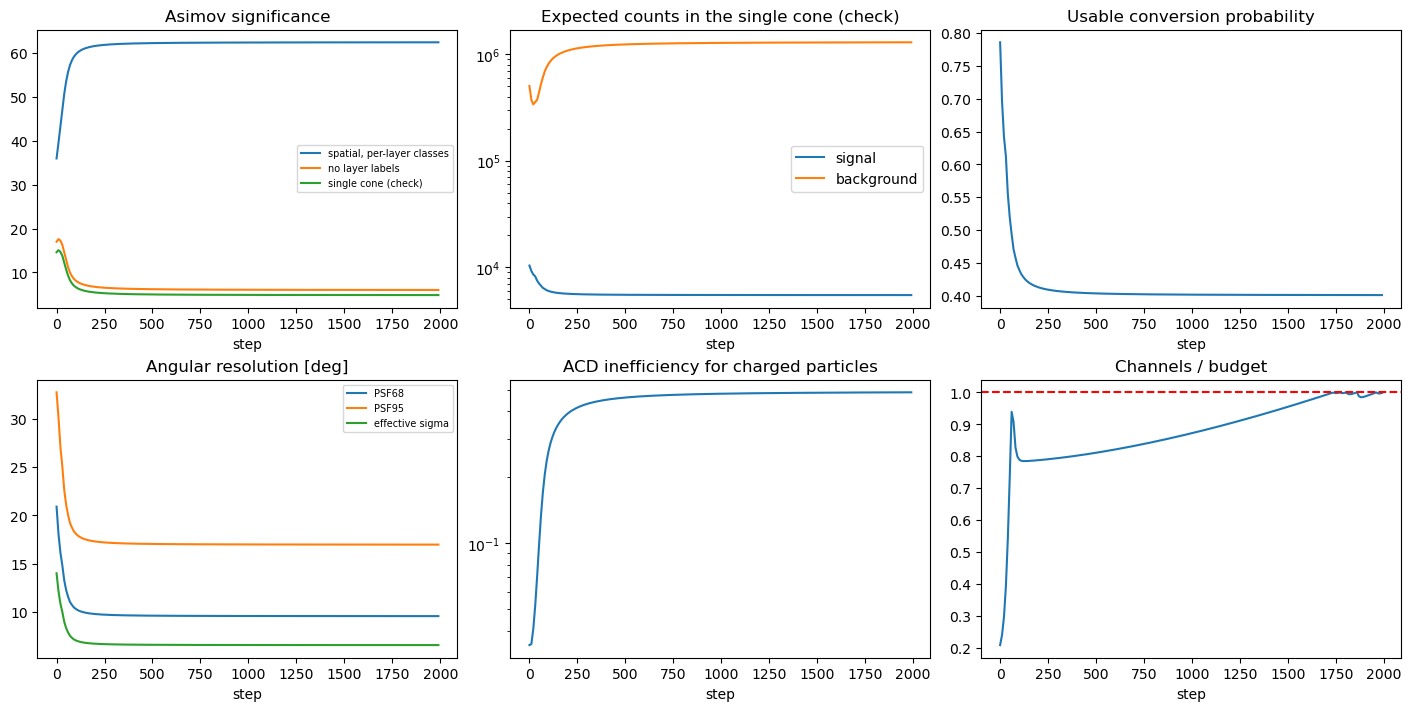

In [10]:
stepNumbers = np.arange(len(optimisationHistory["metrics"])) * recordingInterval
metricsOverSteps = {
    metricName: np.array([recordedEntryAtStep[metricName] for recordedEntryAtStep in optimisationHistory["metrics"]]) for metricName in scalarMetricNames
}

performanceFigure, axesGrid = plt.subplots(2, 3, figsize=(14, 7), constrained_layout=True)
significanceAxis, countsAxis, conversionAxis = axesGrid[0]
resolutionAxis, vetoInefficiencyAxis, channelAxis = axesGrid[1]

significanceAxis.plot(stepNumbers, metricsOverSteps["significance"], label="spatial, per-layer classes")
significanceAxis.plot(stepNumbers, metricsOverSteps["significanceNoLabel"], label="no layer labels")
significanceAxis.plot(stepNumbers, metricsOverSteps["coneSignificance"], label="single cone (check)")
significanceAxis.set(title="Asimov significance", xlabel="step")
significanceAxis.legend(fontsize=7)

countsAxis.plot(stepNumbers, metricsOverSteps["signalCount"], label="signal")
countsAxis.plot(stepNumbers, metricsOverSteps["backgroundCount"], label="background")
countsAxis.set(yscale="log", title="Expected counts in the single cone (check)", xlabel="step")
countsAxis.legend()

conversionAxis.plot(stepNumbers, metricsOverSteps["totalConversionProbability"])
conversionAxis.set(title="Usable conversion probability", xlabel="step")

resolutionAxis.plot(stepNumbers, metricsOverSteps["psf68"], label="PSF68")
resolutionAxis.plot(stepNumbers, metricsOverSteps["psf95"], label="PSF95")
resolutionAxis.plot(stepNumbers, metricsOverSteps["angularResolution"], label="effective sigma")
resolutionAxis.set(title="Angular resolution [deg]", xlabel="step")
resolutionAxis.legend(fontsize=7)

vetoInefficiencyAxis.plot(stepNumbers, 1.0 - metricsOverSteps["vetoEfficiency"])
vetoInefficiencyAxis.set(yscale="log", title="ACD inefficiency for charged particles", xlabel="step")

channelAxis.plot(stepNumbers, metricsOverSteps["numberOfChannels"] / channelBudget)
channelAxis.axhline(1.0, color="red", linestyle="--")   # Above this line the channel budget is violated.
channelAxis.set(title="Channels / budget", xlabel="step")
plt.show()

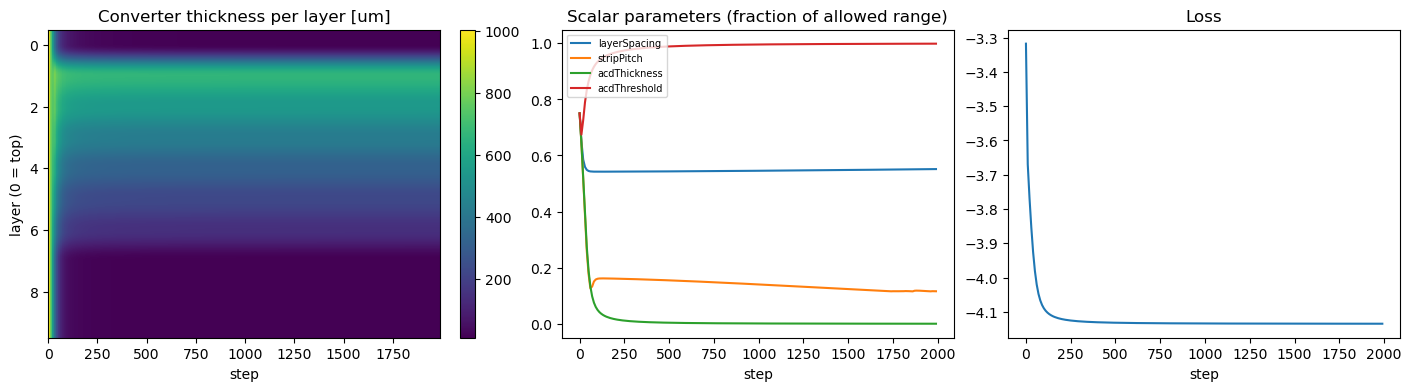

In [11]:
# How the parameters moved. Scalars are shown as a fraction of their allowed range so they share one drawingAxis.
converterThicknessHistory = np.array(
    [recordedEntryAtStep["converterThickness"] for recordedEntryAtStep in optimisationHistory["physicalParameters"]]
)
parameterFigure, (heatmapAxis, scalarParameterAxis, lossAxis) = plt.subplots(1, 3, figsize=(14, 3.8), constrained_layout=True)

micrometersPerCentimeter = 1e4
heatmapImage = heatmapAxis.imshow(
    converterThicknessHistory.T * micrometersPerCentimeter, aspect="auto", origin="lower",
    extent=[0, stepNumbers[-1], -0.5, numberOfLayers - 0.5],
)
heatmapAxis.set(title="Converter thickness per layer [um]", xlabel="step", ylabel="layer (0 = top)")
heatmapAxis.invert_yaxis()
plt.colorbar(heatmapImage, ax=heatmapAxis)

for parameterName in ("layerSpacing", "stripPitch", "acdThickness", "acdThreshold"):
    parameterOverSteps = np.array([recordedEntryAtStep[parameterName] for recordedEntryAtStep in optimisationHistory["physicalParameters"]])
    lowerBound, upperBound = parameterBounds[parameterName]
    scalarParameterAxis.plot(stepNumbers, (parameterOverSteps - lowerBound) / (upperBound - lowerBound), label=parameterName)
scalarParameterAxis.set(title="Scalar parameters (fraction of allowed range)", xlabel="step")
scalarParameterAxis.legend(fontsize=7)

lossAxis.plot(stepNumbers, optimisationHistory["loss"])
lossAxis.set(title="Loss", xlabel="step")
plt.show()

## Design views
Converter thickness is drawn 10x thicker than real so it is visible. The ACD is drawn to scale.

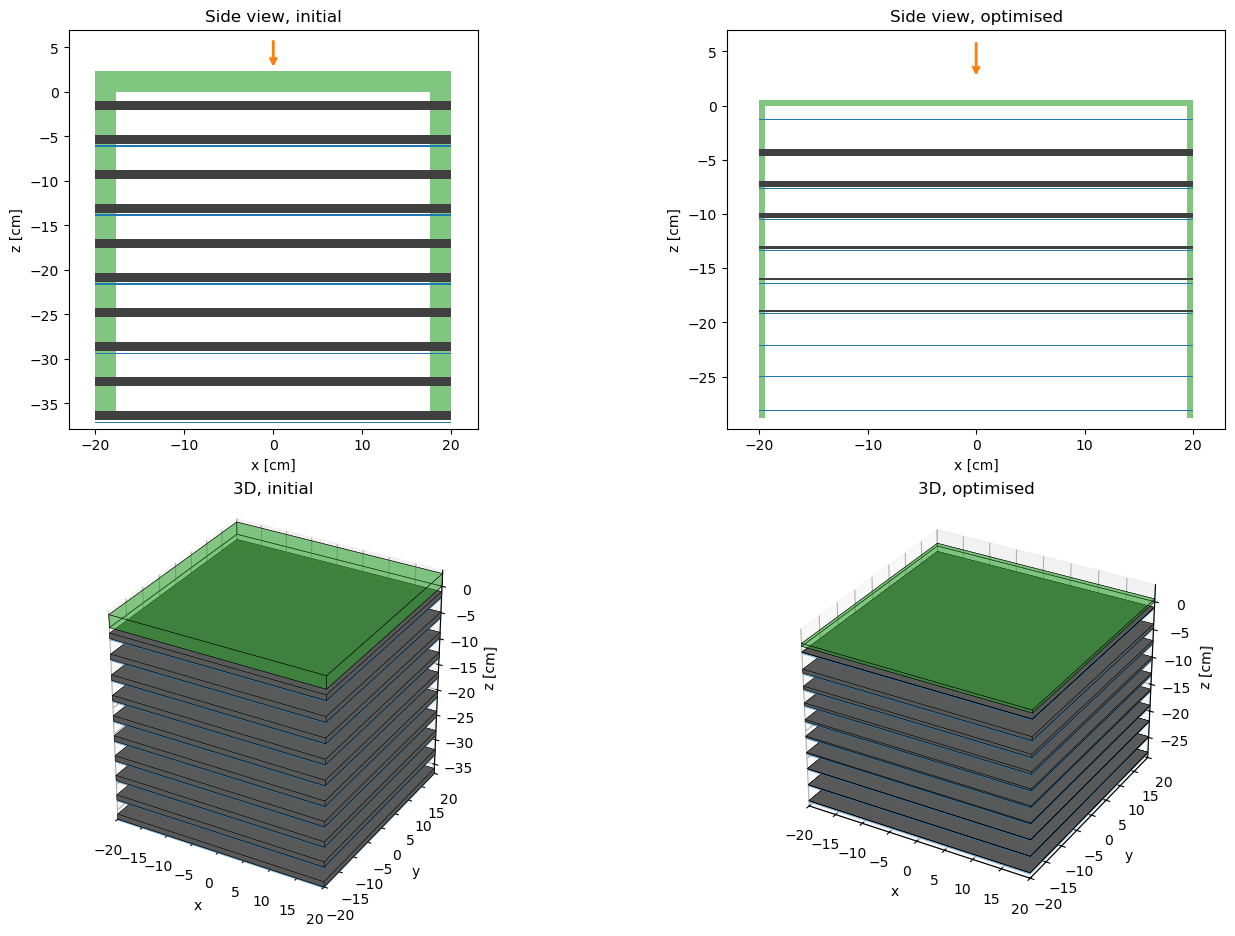

In [12]:
converterDrawingExaggeration = 10.0
siliconPlaneDrawnGap = 0.15         # Distance between the converter and the silicon planes, for drawing only.
siliconPlaneDrawnThickness = 0.05
firstLayerDepth = 1.0               # Gap between the top of the ACD and the first converter.
bottomMargin = 1.0


def computeDrawingGeometry(physicalParameters):
    layerSpacing = float(physicalParameters["layerSpacing"])
    return dict(
        converterDrawnThickness=np.array(physicalParameters["converterThickness"]) * converterDrawingExaggeration,
        acdThickness=float(physicalParameters["acdThickness"]),
        enclosureHeight=firstLayerDepth + (numberOfLayers - 1) * layerSpacing + bottomMargin,
        converterTopHeights=-firstLayerDepth - np.arange(numberOfLayers) * layerSpacing,   # Beam enters at z = 0.
    )


def drawSideView(drawingAxis, physicalParameters, title):
    drawingGeometry = computeDrawingGeometry(physicalParameters)
    halfSide = detectorSideLength / 2.0
    acdThickness = drawingGeometry["acdThickness"]
    enclosureHeight = drawingGeometry["enclosureHeight"]

    # ACD: one plate on top and one on each side.
    drawingAxis.add_patch(Rectangle((-halfSide, 0), detectorSideLength, acdThickness, facecolor="tab:green", alpha=0.6))
    drawingAxis.add_patch(Rectangle((-halfSide, -enclosureHeight), acdThickness, enclosureHeight, facecolor="tab:green", alpha=0.6))
    drawingAxis.add_patch(Rectangle((halfSide - acdThickness, -enclosureHeight), acdThickness, enclosureHeight, facecolor="tab:green", alpha=0.6))

    for layerIndex, converterTop in enumerate(drawingGeometry["converterTopHeights"]):
        converterThicknessDrawn = drawingGeometry["converterDrawnThickness"][layerIndex]
        drawingAxis.add_patch(Rectangle((-halfSide, converterTop - converterThicknessDrawn), detectorSideLength, converterThicknessDrawn, facecolor="0.25"))
        # Two silicon planes (x and y strips) below each converter.
        for planeNumber in (1, 2):
            planeBottom = converterTop - converterThicknessDrawn - planeNumber * siliconPlaneDrawnGap
            drawingAxis.add_patch(Rectangle((-halfSide, planeBottom), detectorSideLength, siliconPlaneDrawnThickness, facecolor="tab:blue"))

    drawingAxis.annotate("", xy=(0, 2.5), xytext=(0, 6), arrowprops=dict(arrowstyle="->", color="tab:orange", lw=2))   # Beam.
    drawingAxis.set(xlim=(-halfSide - 3, halfSide + 3), ylim=(-enclosureHeight - 1, 7), aspect="equal",
             title=title, xlabel="x [cm]", ylabel="z [cm]")


def createBoxFaces(xMin, xMax, yMin, yMax, zMin, zMax):
    cornerCoordinates = np.array([
        [xMin, yMin, zMin], [xMax, yMin, zMin], [xMax, yMax, zMin], [xMin, yMax, zMin],
        [xMin, yMin, zMax], [xMax, yMin, zMax], [xMax, yMax, zMax], [xMin, yMax, zMax],
    ])
    faceCornerIndexSets = [[0, 1, 2, 3], [4, 5, 6, 7], [0, 1, 5, 4], [2, 3, 7, 6], [1, 2, 6, 5], [0, 3, 7, 4]]
    return [[cornerCoordinates[cornerIndex] for cornerIndex in cornerIndicesOfFace] for cornerIndicesOfFace in faceCornerIndexSets]


def drawThreeDimensionalView(drawingAxis, physicalParameters, title):
    drawingGeometry = computeDrawingGeometry(physicalParameters)
    halfSide = detectorSideLength / 2.0
    enclosureHeight = drawingGeometry["enclosureHeight"]

    for layerIndex, converterTop in enumerate(drawingGeometry["converterTopHeights"]):
        converterThicknessDrawn = drawingGeometry["converterDrawnThickness"][layerIndex]
        converterBottom = converterTop - converterThicknessDrawn
        drawingAxis.add_collection3d(Poly3DCollection(
            createBoxFaces(-halfSide, halfSide, -halfSide, halfSide, converterBottom, converterTop),
            facecolor="0.35", edgecolor="black", linewidth=0.3, alpha=0.9))
        drawingAxis.add_collection3d(Poly3DCollection(
            createBoxFaces(-halfSide, halfSide, -halfSide, halfSide, converterBottom - 0.3, converterBottom - 0.2),
            facecolor="tab:blue", alpha=0.4))

    # Only the top ACD plate is drawn: the side plates would hide the tracker.
    drawingAxis.add_collection3d(Poly3DCollection(
        createBoxFaces(-halfSide, halfSide, -halfSide, halfSide, 0, drawingGeometry["acdThickness"]),
        facecolor="tab:green", edgecolor="black", linewidth=0.3, alpha=0.35))

    drawingAxis.set(xlim=(-halfSide, halfSide), ylim=(-halfSide, halfSide), zlim=(-enclosureHeight, 3),
             title=title, xlabel="x", ylabel="y", zlabel="z [cm]")
    drawingAxis.set_box_aspect((detectorSideLength, detectorSideLength, enclosureHeight + 3))
    drawingAxis.quiver(0, 0, 8, 0, 0, -6, color="tab:orange", linewidth=2)   # Beam.


initialPhysicalParameters = mapUnboundedToPhysicalParameters(initialParameters)
optimisedPhysicalParameters = mapUnboundedToPhysicalParameters(optimisedParameters)

designFigure = plt.figure(figsize=(14, 9), constrained_layout=True)
for columnIndex, (designParameters, designName) in enumerate(
    [(initialPhysicalParameters, "initial"), (optimisedPhysicalParameters, "optimised")]
):
    drawSideView(designFigure.add_subplot(2, 2, 1 + columnIndex), designParameters, f"Side view, {designName}")
    drawThreeDimensionalView(designFigure.add_subplot(2, 2, 3 + columnIndex, projection="3d"), designParameters, f"3D, {designName}")
plt.show()

## Per-layer comparison

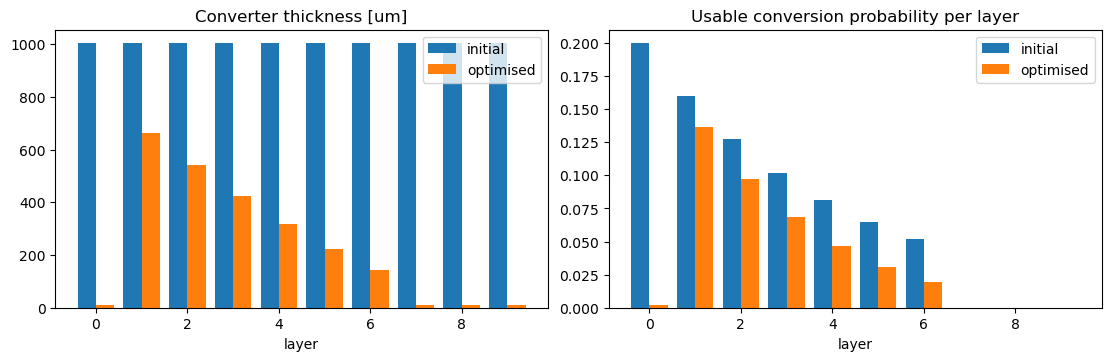

In [13]:
initialResponse = computeMetrics(initialParameters)
optimisedResponse = computeMetrics(optimisedParameters)

layerNumbers = np.arange(numberOfLayers)
barWidth = 0.4
perLayerFigure, (thicknessAxis, conversionPerLayerAxis) = plt.subplots(1, 2, figsize=(11, 3.5), constrained_layout=True)

thicknessAxis.bar(layerNumbers - barWidth / 2, np.array(initialPhysicalParameters["converterThickness"]) * micrometersPerCentimeter, barWidth, label="initial")
thicknessAxis.bar(layerNumbers + barWidth / 2, np.array(optimisedPhysicalParameters["converterThickness"]) * micrometersPerCentimeter, barWidth, label="optimised")
thicknessAxis.set(title="Converter thickness [um]", xlabel="layer")
thicknessAxis.legend()

conversionPerLayerAxis.bar(layerNumbers - barWidth / 2, initialResponse["conversionProbabilityPerLayer"], barWidth, label="initial")
conversionPerLayerAxis.bar(layerNumbers + barWidth / 2, optimisedResponse["conversionProbabilityPerLayer"], barWidth, label="optimised")
conversionPerLayerAxis.set(title="Usable conversion probability per layer", xlabel="layer")
conversionPerLayerAxis.legend()
plt.show()

## Random restarts
The landscape can have several local optima, so start from random designs and compare the final significance.

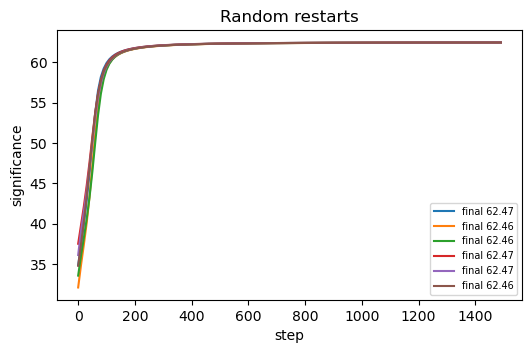

In [14]:
numberOfRestarts = 6   # Numerical choice, no physical source.
# randomSpread=1.5 (spread of the random start in the unbounded space) and numberOfSteps=1500: numerical choices, no physical source.
restartResults = []
for seedNumber in range(numberOfRestarts):
    restartParameters, restartHistory = runOptimisation(
        createInitialParameters(jax.random.PRNGKey(seedNumber), randomSpread=1.5), numberOfSteps=1500
    )
    restartResults.append((float(computeMetrics(restartParameters)["significance"]), restartHistory))

restartFigure, restartAxis = plt.subplots(figsize=(6, 3.5))
for finalSignificance, restartHistory in restartResults:
    restartAxis.plot(
        np.arange(len(restartHistory["metrics"])) * recordingInterval,
        [recordedEntryAtStep["significance"] for recordedEntryAtStep in restartHistory["metrics"]],
        label=f"final {finalSignificance:.2f}",
    )
restartAxis.set(xlabel="step", ylabel="significance", title="Random restarts")
restartAxis.legend(fontsize=7)
plt.show()